# Project 1
- **Part A**:MLP baseline
- **Part B**:自实现CNN并与MLP对比
- **Part C**:
  - 方向 1（优化）: SGD vs Momentum
  - 方向 5（误差分析）: 混淆矩阵与错分样本可视化

In [1]:
import os
import sys
import pickle
import importlib
from struct import unpack

import gzip
import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = os.path.abspath('.')
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

import mynn as nn
importlib.reload(nn.op)
importlib.reload(nn.optimizer)
importlib.reload(nn.lr_scheduler)
importlib.reload(nn.metric)
importlib.reload(nn.runner)
importlib.reload(nn.models)
from draw_tools.plot import plot
from download_mnist import download_mnist

np.random.seed(309)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

download_mnist()

In [2]:
def load_mnist(images_path, labels_path):
    with gzip.open(images_path, 'rb') as f:
        magic, num, rows, cols = unpack('>4I', f.read(16))
        imgs = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows * cols)
    with gzip.open(labels_path, 'rb') as f:
        magic, num = unpack('>2I', f.read(8))
        labs = np.frombuffer(f.read(), dtype=np.uint8)
    return imgs, labs


def prepare_data(seed=309, valid_size=10000):
    data_dir = os.path.join(NOTEBOOK_DIR, 'dataset', 'MNIST')
    train_imgs, train_labs = load_mnist(
        os.path.join(data_dir, 'train-images-idx3-ubyte.gz'),
        os.path.join(data_dir, 'train-labels-idx1-ubyte.gz'),
    )
    test_imgs, test_labs = load_mnist(
        os.path.join(data_dir, 't10k-images-idx3-ubyte.gz'),
        os.path.join(data_dir, 't10k-labels-idx1-ubyte.gz'),
    )

    rng = np.random.RandomState(seed)
    idx = rng.permutation(train_imgs.shape[0])
    train_imgs, train_labs = train_imgs[idx], train_labs[idx]

    valid_imgs = train_imgs[:valid_size]
    valid_labs = train_labs[:valid_size]
    train_imgs = train_imgs[valid_size:]
    train_labs = train_labs[valid_size:]

    max_val = 255.0
    train_imgs = train_imgs / max_val
    valid_imgs = valid_imgs / max_val
    test_imgs = test_imgs / max_val

    return (train_imgs, train_labs), (valid_imgs, valid_labs), (test_imgs, test_labs)


def train_model(model, train_set, valid_set, *, lr=0.06, epochs=5, batch_size=32,
                use_momentum=False, mu=0.9, weight_decay=None, save_dir='./best_models'):
    if use_momentum:
        optimizer = nn.optimizer.MomentGD(init_lr=lr, model=model, mu=mu)
    else:
        optimizer = nn.optimizer.SGD(init_lr=lr, model=model)

    total_iters = int(train_set[0].shape[0] / batch_size + 1) * epochs
    milestones = [int(total_iters * r) for r in [0.3, 0.6, 0.85]]
    scheduler = nn.lr_scheduler.MultiStepLR(optimizer=optimizer, milestones=milestones, gamma=0.5)

    if weight_decay is not None:
        for layer in model.layers:
            if hasattr(layer, 'weight_decay'):
                layer.weight_decay = True
                layer.weight_decay_lambda = weight_decay

    loss_fn = nn.op.MultiCrossEntropyLoss(model=model, max_classes=10)
    runner = nn.runner.RunnerM(model, optimizer, nn.metric.accuracy, loss_fn,
                               batch_size=batch_size, scheduler=scheduler)
    runner.train(train_set, valid_set, num_epochs=epochs, log_iters=200, save_dir=save_dir)
    return runner


def plot_learning_curves(runner, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot(runner, axes)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def evaluate_on_test(model, test_set):
    X, y = test_set
    logits = model(X)
    return nn.metric.accuracy(logits, y)


(train_set, valid_set, test_set) = prepare_data()
print(f'Train: {train_set[0].shape}, Valid: {valid_set[0].shape}, Test: {test_set[0].shape}')

Train: (50000, 784), Valid: (10000, 784), Test: (10000, 784)


## Part A: MLP 基线模型

结构: `784 -> 600 -> ReLU -> 10`，使用 SGD + MultiStepLR 学习率调度，L2 权重衰减 `1e-4`。

epoch: 0, iteration: 0
[Train] loss: 2.303875516321773, score: 0.03125
[Dev] loss: 2.3016638334118094, score: 0.0773
epoch: 0, iteration: 200
[Train] loss: 2.2780112797507672, score: 0.59375
[Dev] loss: 2.282525887559151, score: 0.4891
epoch: 0, iteration: 400
[Train] loss: 2.2582711695546, score: 0.625
[Dev] loss: 2.2617035734095277, score: 0.5793
epoch: 0, iteration: 600
[Train] loss: 2.2527209376956345, score: 0.5625
[Dev] loss: 2.236135287150333, score: 0.6487
epoch: 0, iteration: 800
[Train] loss: 2.2116254508274844, score: 0.65625
[Dev] loss: 2.204798884127446, score: 0.6868
epoch: 0, iteration: 1000
[Train] loss: 2.153460232704525, score: 0.65625
[Dev] loss: 2.164233297748032, score: 0.6705
epoch: 0, iteration: 1200
[Train] loss: 2.1312388911454816, score: 0.71875
[Dev] loss: 2.1135499356035368, score: 0.6782
epoch: 0, iteration: 1400
[Train] loss: 2.0269307244955903, score: 0.71875
[Dev] loss: 2.0496686092485006, score: 0.6742
best accuracy performence has been updated: 0.00000

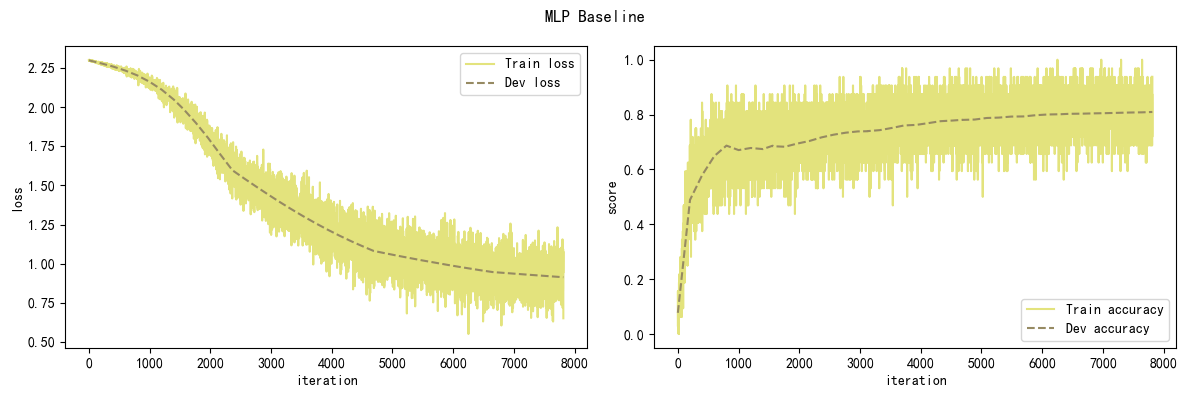

MLP best valid acc: 0.8095, test acc: 0.8172


In [5]:
mlp_model = nn.models.Model_MLP([784, 600, 10], 'ReLU', [1e-4, 1e-4])
mlp_runner = train_model(
    mlp_model, train_set, valid_set,
    lr=0.06, epochs=5, batch_size=32,
    save_dir='./best_models/mlp'
)
plot_learning_curves(mlp_runner, 'MLP Baseline')

mlp_model.load_model('./best_models/mlp/best_model.pickle')
mlp_valid_acc = mlp_runner.best_score
mlp_test_acc = evaluate_on_test(mlp_model, test_set)
print(f'MLP best valid acc: {mlp_valid_acc:.4f}, test acc: {mlp_test_acc:.4f}')

## Part B: CNN 模型与 MLP 对比

CNN 结构: 3 层卷积 (8/16/32 通道) + 2 层全连接。与 MLP 使用相同的学习率、batch size、epoch。

epoch: 0, iteration: 0
[Train] loss: 2.3039363331264453, score: 0.0625
[Dev] loss: 2.3029184924763313, score: 0.0934
epoch: 0, iteration: 200
[Train] loss: 2.300736655893311, score: 0.21875
[Dev] loss: 2.3013943497786613, score: 0.136
epoch: 0, iteration: 400
[Train] loss: 2.2985395157794066, score: 0.3125
[Dev] loss: 2.299729568723237, score: 0.2106
epoch: 0, iteration: 600
[Train] loss: 2.297877713626759, score: 0.34375
[Dev] loss: 2.2978543985009794, score: 0.2912
epoch: 0, iteration: 800
[Train] loss: 2.2959229643255687, score: 0.25
[Dev] loss: 2.2955042696277452, score: 0.2864
epoch: 0, iteration: 1000
[Train] loss: 2.291050178018634, score: 0.375
[Dev] loss: 2.2925009953046285, score: 0.3519
epoch: 0, iteration: 1200
[Train] loss: 2.291306002434377, score: 0.46875
[Dev] loss: 2.288532233848053, score: 0.4608
epoch: 0, iteration: 1400
[Train] loss: 2.2823131234919165, score: 0.40625
[Dev] loss: 2.2831401749833318, score: 0.4418
best accuracy performence has been updated: 0.00000 -

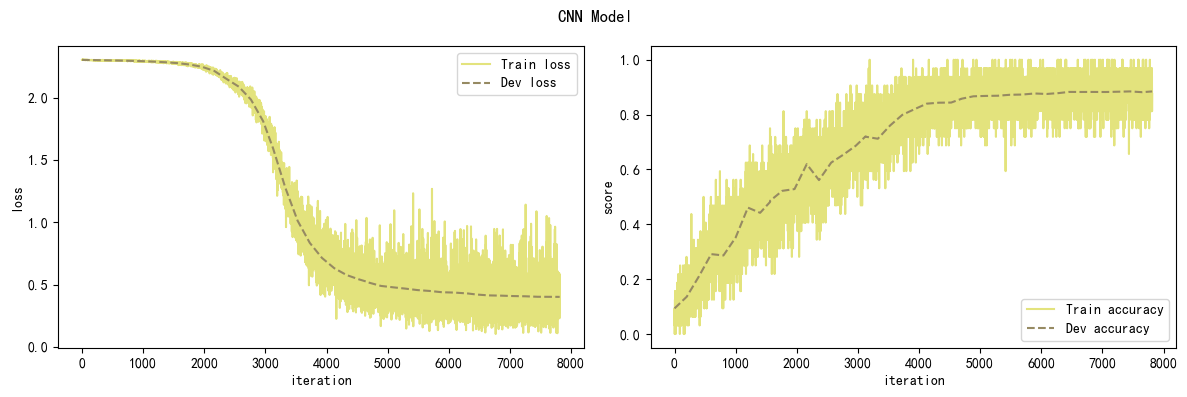

CNN best valid acc: 0.8844, test acc: 0.8940


In [3]:
cnn_model = nn.models.Model_CNN()
cnn_runner = train_model(
    cnn_model, train_set, valid_set,
    lr=0.06, epochs=5, batch_size=32,
    save_dir='./best_models/cnn'
)
plot_learning_curves(cnn_runner, 'CNN Model')

cnn_model.load_model('./best_models/cnn/best_model.pickle')
cnn_valid_acc = cnn_runner.best_score
cnn_test_acc = evaluate_on_test(cnn_model, test_set)
print(f'CNN best valid acc: {cnn_valid_acc:.4f}, test acc: {cnn_test_acc:.4f}')

In [6]:
print('=' * 50)
print(f'{"Model":<10} {"Valid Acc":<12} {"Test Acc":<12}')
print('-' * 50)
print(f'{"MLP":<10} {mlp_valid_acc:<12.4f} {mlp_test_acc:<12.4f}')
print(f'{"CNN":<10} {cnn_valid_acc:<12.4f} {cnn_test_acc:<12.4f}')
print('=' * 50)

Model      Valid Acc    Test Acc    
--------------------------------------------------
MLP        0.8095       0.8172      
CNN        0.8844       0.8940      


## Part C - 方向 1: 优化 (Momentum)

在相同 MLP 结构下，对比普通 SGD 与带动量的 MomentGD (μ=0.9)。

epoch: 0, iteration: 0
[Train] loss: 2.2932870297869066, score: 0.25
[Dev] loss: 2.3015130225863416, score: 0.0909
epoch: 0, iteration: 200
[Train] loss: 2.2833609220733435, score: 0.3125
[Dev] loss: 2.2826030629172633, score: 0.361
epoch: 0, iteration: 400
[Train] loss: 2.270064750550702, score: 0.375
[Dev] loss: 2.261102722421002, score: 0.5077
epoch: 0, iteration: 600
[Train] loss: 2.2352038804964183, score: 0.65625
[Dev] loss: 2.235435819292095, score: 0.5904
epoch: 0, iteration: 800
[Train] loss: 2.1943640943065823, score: 0.625
[Dev] loss: 2.202905346285049, score: 0.6114
epoch: 0, iteration: 1000
[Train] loss: 2.19218508342038, score: 0.4375
[Dev] loss: 2.161267285863989, score: 0.6178
epoch: 0, iteration: 1200
[Train] loss: 2.0476062504494648, score: 0.8125
[Dev] loss: 2.1092752032628606, score: 0.6532
epoch: 0, iteration: 1400
[Train] loss: 2.0267677711891228, score: 0.65625
[Dev] loss: 2.04611240876811, score: 0.6614
best accuracy performence has been updated: 0.00000 --> 0.6

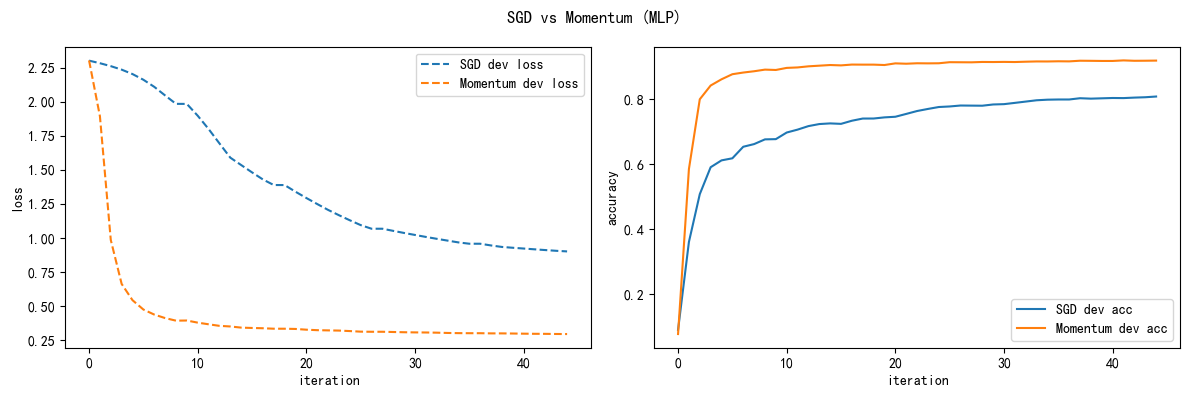

SGD      valid: 0.8074, test: 0.8173
Momentum valid: 0.9177, test: 0.9239


In [7]:
mlp_sgd = nn.models.Model_MLP([784, 600, 10], 'ReLU', [1e-4, 1e-4])
sgd_runner = train_model(
    mlp_sgd, train_set, valid_set,
    lr=0.06, epochs=5, batch_size=32, use_momentum=False,
    save_dir='./best_models/mlp_sgd'
)

mlp_momentum = nn.models.Model_MLP([784, 600, 10], 'ReLU', [1e-4, 1e-4])
mom_runner = train_model(
    mlp_momentum, train_set, valid_set,
    lr=0.06, epochs=5, batch_size=32, use_momentum=True, mu=0.9,
    save_dir='./best_models/mlp_momentum'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sgd_runner.dev_loss, label='SGD dev loss', linestyle='--')
axes[0].plot(mom_runner.dev_loss, label='Momentum dev loss', linestyle='--')
axes[0].set_xlabel('iteration'); axes[0].set_ylabel('loss'); axes[0].legend()
axes[1].plot(sgd_runner.dev_scores, label='SGD dev acc')
axes[1].plot(mom_runner.dev_scores, label='Momentum dev acc')
axes[1].set_xlabel('iteration'); axes[1].set_ylabel('accuracy'); axes[1].legend()
fig.suptitle('SGD vs Momentum (MLP)')
plt.tight_layout(); plt.show()

mlp_sgd.load_model('./best_models/mlp_sgd/best_model.pickle')
mlp_momentum.load_model('./best_models/mlp_momentum/best_model.pickle')
print(f'SGD      valid: {sgd_runner.best_score:.4f}, test: {evaluate_on_test(mlp_sgd, test_set):.4f}')
print(f'Momentum valid: {mom_runner.best_score:.4f}, test: {evaluate_on_test(mlp_momentum, test_set):.4f}')

## Part C - 方向 5: 误差分析与可视化

对最佳 CNN 模型绘制混淆矩阵、展示错分样本，并可视化第一层卷积核。

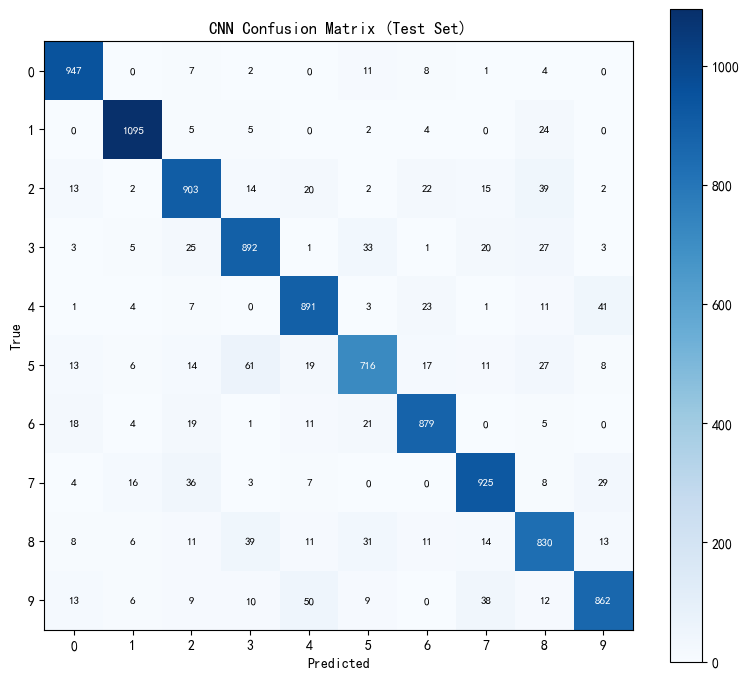

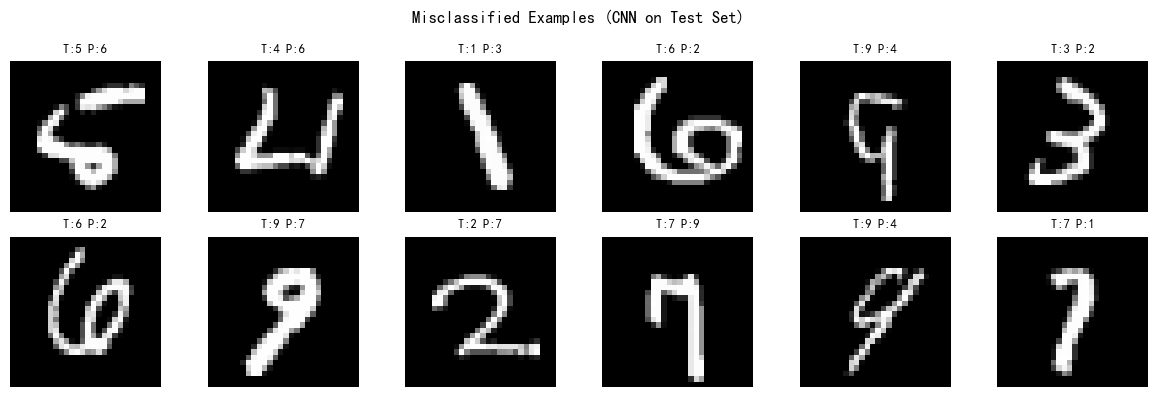

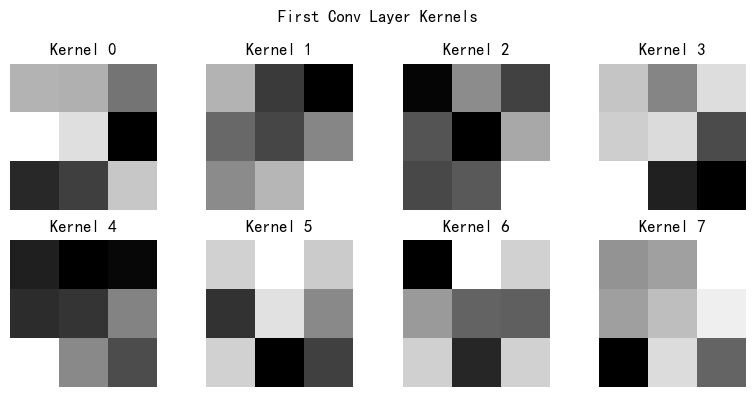

In [8]:
def confusion_matrix(model, dataset, num_classes=10):
    X, y = dataset
    preds = np.argmax(model(X), axis=1)
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y, preds):
        cm[t, p] += 1
    return cm


def plot_confusion_matrix(cm, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_title(title)
    for i in range(10):
        for j in range(10):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() * 0.5 else 'black', fontsize=8)
    plt.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()


def plot_misclassified(model, dataset, max_show=12):
    X, y = dataset
    preds = np.argmax(model(X), axis=1)
    wrong_idx = np.where(preds != y)[0][:max_show]
    n = len(wrong_idx)
    cols = min(6, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, idx in zip(axes, wrong_idx):
        ax.imshow(X[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f'T:{y[idx]} P:{preds[idx]}', fontsize=9)
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle('Misclassified Examples (CNN on Test Set)')
    plt.tight_layout(); plt.show()


def plot_conv_kernels(model, max_kernels=16):
    conv_layer = model.layers[0]
    kernels = conv_layer.W[:, 0, :, :]
    n = min(max_kernels, kernels.shape[0])
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(8, 2 * rows))
    axes = np.array(axes).reshape(-1)
    for i in range(n):
        axes[i].imshow(kernels[i], cmap='gray')
        axes[i].set_title(f'Kernel {i}'); axes[i].axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle('First Conv Layer Kernels')
    plt.tight_layout(); plt.show()


cm = confusion_matrix(cnn_model, test_set)
plot_confusion_matrix(cm, 'CNN Confusion Matrix (Test Set)')
plot_misclassified(cnn_model, test_set)
plot_conv_kernels(cnn_model)

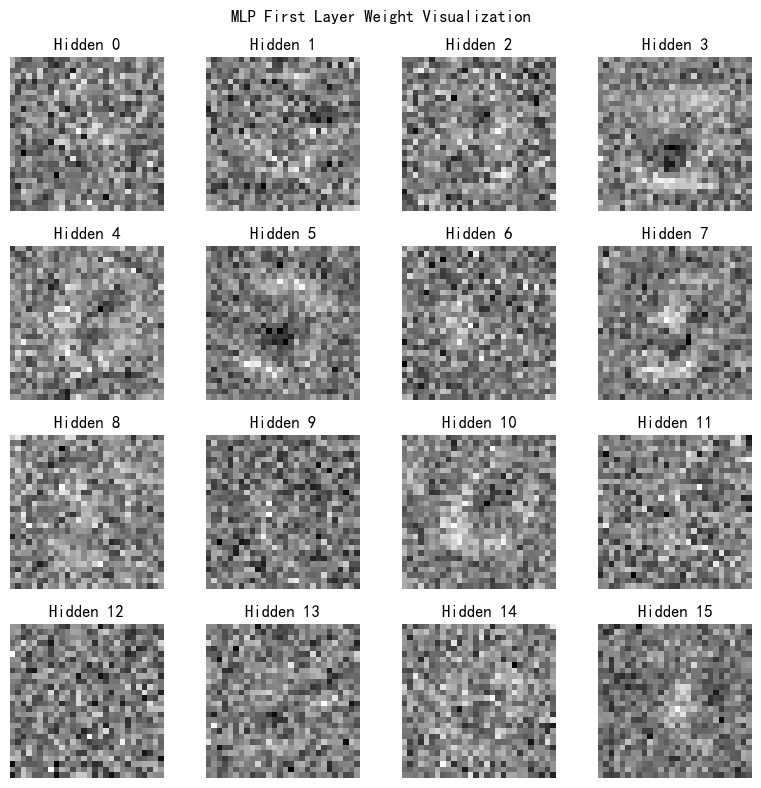

In [10]:
def plot_mlp_weights(model, max_neurons=16):
    first_linear = model.layers[0]
    weights = first_linear.W.T  # [hidden_dim, 784]

    n = min(max_neurons, weights.shape[0])
    cols = 4
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(8, 2 * rows))
    axes = np.array(axes).reshape(-1)

    for i in range(n):
        axes[i].imshow(weights[i].reshape(28, 28), cmap='gray')
        axes[i].set_title(f'Hidden {i}')
        axes[i].axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    fig.suptitle('MLP First Layer Weight Visualization')
    plt.tight_layout()
    plt.show()

plot_mlp_weights(mlp_model)

## 最终结果汇总

In [9]:
results = [
    ('MLP Baseline', mlp_valid_acc, mlp_test_acc),
    ('CNN', cnn_valid_acc, cnn_test_acc),
    ('MLP + SGD', sgd_runner.best_score, evaluate_on_test(mlp_sgd, test_set)),
    ('MLP + Momentum', mom_runner.best_score, evaluate_on_test(mlp_momentum, test_set)),
]

print(f'{"Experiment":<20} {"Valid Acc":<12} {"Test Acc":<12}')
print('-' * 44)
for name, va, ta in results:
    print(f'{name:<20} {va:<12.4f} {ta:<12.4f}')

Experiment           Valid Acc    Test Acc    
--------------------------------------------
MLP Baseline         0.8095       0.8172      
CNN                  0.8844       0.8940      
MLP + SGD            0.8074       0.8173      
MLP + Momentum       0.9177       0.9239      
